<a href="https://colab.research.google.com/github/chavezaltamirano-ui/wdi-panel-mx-us-cn-br-ru/blob/main/proyecto_Antonio_Chavez_Altamirano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre: Antonio Chávez Altamirano


# Tarea - Ciencia de Datos con SQL y Matplotlib

## Dataset utilizado

Para el desarrollo de esta actividad se utilizó un conjunto de datos real derivado de los indicadores del Banco Mundial (World Development Indicators, WDI).

**Dataset principal:** WDI_completo_panel.csv

**Archivos complementarios:**
- WDI_completo_panel.parquet
- catalogo_indicadores.csv

**Fuente:**
Repositorio de GitHub del proyecto WDI Panel MX-US-CN-BR-RU.

**Descripción:**

El dataset contiene información económica, social y de desarrollo para México, Estados Unidos, China, Brasil y Rusia. Los datos corresponden a múltiples indicadores del Banco Mundial organizados en formato panel, permitiendo realizar análisis comparativos entre países y a través del tiempo.

Los archivos complementarios incluyen una versión optimizada en formato Parquet y un catálogo con la descripción de los indicadores utilizados en el análisis.

## Objetivos

- Realizar consultas SQL sobre los datos.
- Analizar indicadores de desarrollo económico y social.
- Generar visualizaciones con Matplotlib.
- Obtener conclusiones a partir de los resultados obtenidos.

Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Leer el dataset directamente desde GitHub

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/chavezaltamirano-ui/wdi-panel-mx-us-cn-br-ru/main/data/WDI_completo_panel.csv"

df = pd.read_csv(url)

df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal,pais,indicador
0,"{'id': '1.0.HCount.1.90usd', 'value': 'Poverty...","{'id': 'MEX', 'value': 'Mexico'}",NaN,2014,5.653357,NaN,NaN,0.0,MX,1.0.HCount.1.90usd
1,"{'id': '1.0.HCount.1.90usd', 'value': 'Poverty...","{'id': 'MEX', 'value': 'Mexico'}",NaN,2012,5.944242,NaN,NaN,0.0,MX,1.0.HCount.1.90usd
2,"{'id': '1.0.HCount.1.90usd', 'value': 'Poverty...","{'id': 'MEX', 'value': 'Mexico'}",NaN,2010,6.593106,NaN,NaN,0.0,MX,1.0.HCount.1.90usd
3,"{'id': '1.0.HCount.1.90usd', 'value': 'Poverty...","{'id': 'MEX', 'value': 'Mexico'}",NaN,2008,7.191222,NaN,NaN,0.0,MX,1.0.HCount.1.90usd
4,"{'id': '1.0.HCount.1.90usd', 'value': 'Poverty...","{'id': 'MEX', 'value': 'Mexico'}",NaN,2006,6.033171,NaN,NaN,0.0,MX,1.0.HCount.1.90usd


# Exploración inicial del dataset

Antes de realizar las consultas SQL, se explora la estructura general del conjunto de datos para conocer su tamaño, variables disponibles y características principales.

1. Dimensiones del dataset

In [ ]:
filas, columnas = df.shape

print(f"Total de registros: {filas}")
print(f"Total de columnas: {columnas}")

Total de registros: 11058
Total de columnas: 10


2. Información general

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11058 entries, 0 to 11057
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        11058 non-null  object 
 1   country          11058 non-null  object 
 2   countryiso3code  0 non-null      float64
 3   date             11058 non-null  int64  
 4   value            11058 non-null  float64
 5   unit             0 non-null      float64
 6   obs_status       0 non-null      float64
 7   decimal          11058 non-null  float64
 8   pais             11058 non-null  object 
 9   indicador        11058 non-null  object 
dtypes: float64(5), int64(1), object(4)
memory usage: 864.0+ KB


3. Nombres de las columnas

In [ ]:
df.columns.tolist()

['indicator',
 'country',
 'countryiso3code',
 'date',
 'value',
 'unit',
 'obs_status',
 'decimal',
 'pais',
 'indicador']

4. Número de países

In [ ]:
print(df['pais'].nunique())


5


5. Número de indicadores

In [ ]:
print(df['indicador'].nunique())

156


6. Período de tiempo cubierto


In [ ]:
print("Año mínimo:", df['date'].min())
print("Año máximo:", df['date'].max())

Año mínimo: 1990
Año máximo: 2016


7. Tamaño del dataset

In [ ]:
df.shape

(11058, 10)

8, Valores faltantes

In [ ]:
df.isnull().sum()

,0
indicator,0
country,0
countryiso3code,11058
date,0
value,0
unit,11058
obs_status,11058
decimal,0
pais,0
indicador,0


# Consultas SQL

En esta sección se realizan 10 consultas SQL sobre el dataset para obtener información relevante y analizar los datos.


Configuración de SQL

In [ ]:
!pip install pandasql

In [ ]:
from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())

Cpnsulta 1. Total de registros

In [ ]:
consulta1 = """
SELECT COUNT(*) AS total_registros
FROM df
"""

pysqldf(consulta1)

,total_registros
0,11058


Consulta 2. Países disponibles

In [ ]:
consulta2 = """
SELECT DISTINCT pais
FROM df
"""

pysqldf(consulta2)

,pais
0,MX
1,BR
2,US
3,CN
4,RU


Consulta 3. Total de indicadores

In [ ]:
consulta3 = """
SELECT COUNT(DISTINCT indicador) AS total_indicadores
FROM df
"""

pysqldf(consulta3)

,total_indicadores
0,156


Consulta 4. Año mínimo y máximo

In [ ]:
consulta4 = """
SELECT
MIN(date) AS primer_anio,
MAX(date) AS ultimo_anio
FROM df
"""

pysqldf(consulta4)

,primer_anio,ultimo_anio
0,1990,2016


Consulta 5. Registros por país

In [ ]:
consulta5 = """
SELECT pais,
COUNT(*) AS total
FROM df
GROUP BY pais
ORDER BY total DESC
"""

pysqldf(consulta5)

,pais,total
0,BR,4753
1,MX,3725
2,US,860
3,RU,860
4,CN,860


Consulta 6. Confirmar las columnas:


In [ ]:
print(df.columns.tolist())

['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit', 'obs_status', 'decimal', 'pais', 'indicador']


In [ ]:
Consulta 7. Top 10 valores más altos

In [ ]:
consulta7 = """
SELECT indicador,
pais,
date,
value
FROM df
ORDER BY value DESC
LIMIT 10
"""

pysqldf(consulta7)

,indicador,pais,date,value
0,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2015,7.318315e+07
1,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2015,7.318315e+07
2,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2015,7.318315e+07
3,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2015,7.318315e+07
4,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2014,7.153631e+07
5,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2014,7.153631e+07
6,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2014,7.153631e+07
7,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2014,7.153631e+07
8,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2013,6.990654e+07
9,1.1_TOTAL.FINAL.ENERGY.CONSUM,CN,2013,6.990654e+07


Consulta 8. Top 10 valores más bajos

In [ ]:
consulta8 = """
SELECT indicador,
pais,
date,
value
FROM df
ORDER BY value ASC
LIMIT 10
"""

pysqldf(consulta8)

,indicador,pais,date,value
0,3.0.IncShr.q1,MX,2000,0.032739
1,3.0.IncShr.q1,MX,2000,0.032739
2,3.0.IncShr.q1,MX,2000,0.032739
3,3.0.IncShr.q1,MX,2000,0.032739
4,3.0.IncShr.q1,MX,2005,0.036946
5,3.0.IncShr.q1,MX,2005,0.036946
6,3.0.IncShr.q1,MX,2005,0.036946
7,3.0.IncShr.q1,MX,2005,0.036946
8,3.0.IncShr.q1,MX,2002,0.037732
9,3.0.IncShr.q1,MX,2002,0.037732


Consulta 9. Exploración de los indicadores disponibles en el dataset

In [ ]:
pd.set_option('display.max_colwidth', None)

df[['indicador']].drop_duplicates().head(50)

,indicador
0,1.0.HCount.1.90usd
21,1.0.HCount.2.5usd
42,1.0.HCount.Mid10to50
63,1.0.HCount.Ofcl
85,1.0.HCount.Poor4uds
106,1.0.HCount.Vul4to10
127,1.0.PGap.1.90usd
148,1.0.PGap.2.5usd
169,1.0.PGap.Poor4uds
190,1.0.PSev.1.90usd


Consulta 10, Descripción humana de los indicadores.

In [ ]:
catalogo = pd.read_csv(
    "https://raw.githubusercontent.com/chavezaltamirano-ui/wdi-panel-mx-us-cn-br-ru/main/data/catalogo_indicadores.csv"
)

catalogo.head(20)

,id,name,unit,sourceNote,sourceOrganization,topics,source.id,source.value
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),NaN,The poverty headcount index measures the proportion of the population with daily per capita income (in 2011 PPP) below the poverty line.,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),NaN,The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,NaN,The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,NaN,The poverty headcount index measures the proportion of the population with daily per capita income below the official poverty line developed by each country.,LAC Equity Lab tabulations of data from National Statistical Offices.,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),NaN,The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
5,1.0.HCount.Vul4to10,Vulnerable ($4-10 a day) Headcount,NaN,The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
6,1.0.PGap.1.90usd,Poverty Gap ($1.90 a day),NaN,The poverty gap captures the mean aggregate income or consumption shortfall relative to the poverty line across the entire population. It measures the total resources needed to bring all the poor to the level of the poverty line (averaged over the total population).,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
7,1.0.PGap.2.5usd,Poverty Gap ($2.50 a day),NaN,The poverty gap captures the mean aggregate income or consumption shortfall relative to the poverty line across the entire population. It measures the total resources needed to bring all the poor to the level of the poverty line (averaged over the total population).,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
8,1.0.PGap.Poor4uds,Poverty Gap ($4 a day),NaN,The poverty gap captures the mean aggregate income or consumption shortfall relative to the poverty line across the entire population. It measures the total resources needed to bring all the poor to the level of the poverty line (averaged over the total population).,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab
9,1.0.PSev.1.90usd,Poverty Severity ($1.90 a day),NaN,The poverty severity index combines information on both poverty and inequality among the poor by averaging the squares of the poverty gaps relative the poverty line,LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).,"[{'id': '11', 'value': 'Poverty '}]",37,LAC Equity Lab


### Consulta 9. Comparación de pobreza extrema entre países


In [ ]:
consulta9 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS pobreza_promedio
FROM df
WHERE indicador = '1.0.HCount.1.90usd'
GROUP BY pais
ORDER BY pobreza_promedio DESC
"""

pysqldf(consulta9)

,pais,pobreza_promedio
0,BR,8.42
1,MX,7.70


### Consulta 10. Comparación del acceso total a electricidad entre países

In [ ]:
consulta10 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS acceso_electricidad
FROM df
WHERE indicador = '1.1_ACCESS.ELECTRICITY.TOT'
GROUP BY pais
ORDER BY acceso_electricidad DESC
"""

pysqldf(consulta10)

,pais,acceso_electricidad
0,US,100.00
1,RU,100.00
2,MX,97.49
3,CN,96.92
4,BR,95.64


In [ ]:
consulta11 = """
SELECT
    indicador,
    COUNT(*) AS registros
FROM df
WHERE value IS NOT NULL
GROUP BY indicador
ORDER BY registros DESC
LIMIT 20
"""

pysqldf(consulta11)

,indicador,registros
0,1.3_ACCESS.ELECTRICITY.URBAN,540
1,1.2_ACCESS.ELECTRICITY.RURAL,540
2,1.1_ACCESS.ELECTRICITY.TOT,540
3,3.1_RE.CONSUMPTION,520
4,2.1_SHARE.TOTAL.RE.IN.TFEC,520
5,1.1_TOTAL.FINAL.ENERGY.CONSUM,520
6,2.1_ACCESS.CFT.TOT,340
7,4.1_SHARE.RE.IN.ELECTRICITY,260
8,4.1.2_REN.ELECTRICITY.OUTPUT,260
9,4.1.1_TOTAL.ELECTRICITY.OUTPUT,260


### Consulta 11. Comparación del acceso total a electricidad entre países

In [ ]:
consulta11 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS acceso_total
FROM df
WHERE indicador = '1.1_ACCESS.ELECTRICITY.TOT'
GROUP BY pais
ORDER BY acceso_total DESC
"""

pysqldf(consulta11)

,pais,acceso_total
0,US,100.00
1,RU,100.00
2,MX,97.49
3,CN,96.92
4,BR,95.64


### Consulta 12. Comparación del acceso rural a electricidad entre países

In [ ]:
consulta12 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS acceso_rural
FROM df
WHERE indicador = '1.2_ACCESS.ELECTRICITY.RURAL'
GROUP BY pais
ORDER BY acceso_rural DESC
"""

pysqldf(consulta12)

,pais,acceso_rural
0,US,100.00
1,RU,100.00
2,CN,95.41
3,MX,91.78
4,BR,80.25


### Consulta 13. Comparación del acceso urbano a electricidad entre países

In [ ]:
consulta13 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS acceso_urbano
FROM df
WHERE indicador = '1.3_ACCESS.ELECTRICITY.URBAN'
GROUP BY pais
ORDER BY acceso_urbano DESC
"""

pysqldf(consulta13)

,pais,acceso_urbano
0,US,100.00
1,RU,100.00
2,CN,99.78
3,MX,99.38
4,BR,99.25


### Consulta 14. Comparación del consumo final de energía entre países

In [ ]:
consulta14 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS consumo_energia
FROM df
WHERE indicador = '1.1_TOTAL.FINAL.ENERGY.CONSUM'
GROUP BY pais
ORDER BY consumo_energia DESC
"""

pysqldf(consulta14)

,pais,consumo_energia
0,US,55615204.02
1,CN,43316577.65
2,RU,17059973.64
3,BR,6458536.20
4,MX,3946949.06


### Consulta 15. Comparación del consumo de energías renovables entre países

In [ ]:
consulta15 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS consumo_renovable
FROM df
WHERE indicador = '3.1_RE.CONSUMPTION'
GROUP BY pais
ORDER BY consumo_renovable DESC
"""

pysqldf(consulta15)

,pais,consumo_renovable
0,CN,8611428.54
1,US,3346371.96
2,BR,2929968.58
3,RU,617297.33
4,MX,429022.71


### Consulta 16. Participación de energías renovables dentro del consumo energético total

In [ ]:
consulta16 = """
SELECT
    pais,
    ROUND(AVG(value),2) AS porcentaje_renovable
FROM df
WHERE indicador = '2.1_SHARE.TOTAL.RE.IN.TFEC'
GROUP BY pais
ORDER BY porcentaje_renovable DESC
"""

pysqldf(consulta16)

,pais,porcentaje_renovable
0,BR,45.60
1,CN,22.90
2,MX,11.11
3,US,5.96
4,RU,3.60


# Visualizaciones del Dataset

A continuación se presentan diversas visualizaciones construidas a partir de las consultas SQL realizadas anteriormente. El objetivo es comparar indicadores de acceso a energía y uso de recursos energéticos entre México, Estados Unidos, China, Brasil y Rusia.

## Gráfica 1. Acceso total a electricidad por país

Esta gráfica compara el acceso promedio a electricidad entre los países analizados. El indicador permite identificar el nivel de cobertura eléctrica alcanzado por cada nación.

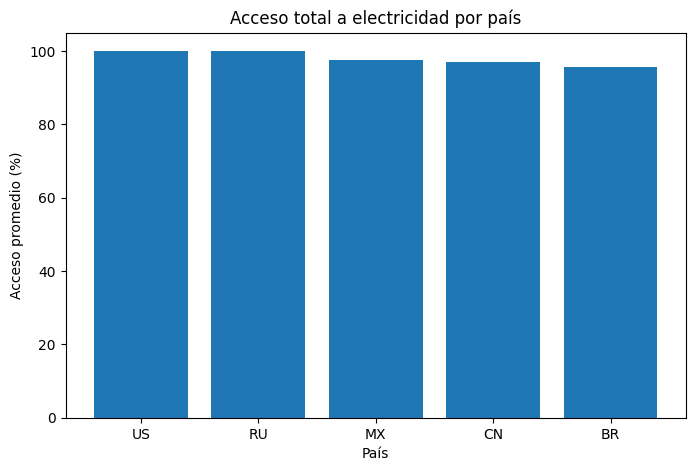

In [ ]:
resultado11 = pysqldf(consulta11)

plt.figure(figsize=(8,5))
plt.bar(
    resultado11['pais'],
    resultado11['acceso_total']
)

plt.title('Acceso total a electricidad por país')
plt.xlabel('País')
plt.ylabel('Acceso promedio (%)')

plt.show()

### Interpretación

La gráfica permite identificar qué países presentan una mayor cobertura eléctrica. Los países con valores cercanos al 100 % muestran una mayor capacidad de infraestructura y acceso a servicios básicos para su población.

## Gráfica 2. Acceso rural a electricidad

El acceso a electricidad en zonas rurales es un indicador importante de desarrollo social y reducción de desigualdades territoriales.

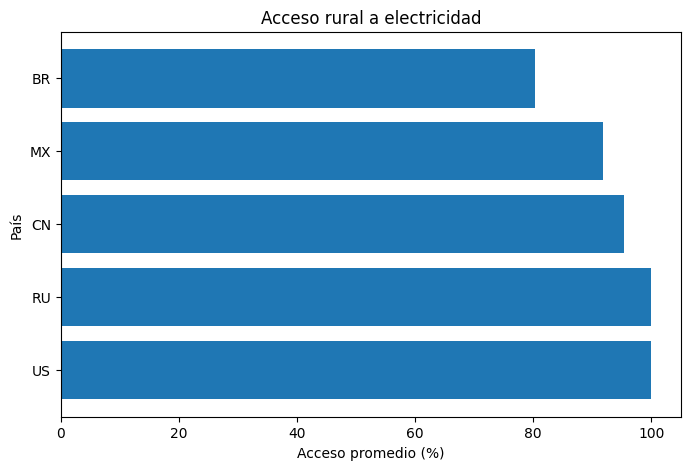

In [ ]:
resultado12 = pysqldf(consulta12)

plt.figure(figsize=(8,5))

plt.barh(
    resultado12['pais'],
    resultado12['acceso_rural']
)

plt.title('Acceso rural a electricidad')
plt.xlabel('Acceso promedio (%)')
plt.ylabel('País')

plt.show()

## Gráfica 3. Acceso urbano a electricidad

Esta visualización muestra el nivel de acceso a electricidad en áreas urbanas de los países analizados.


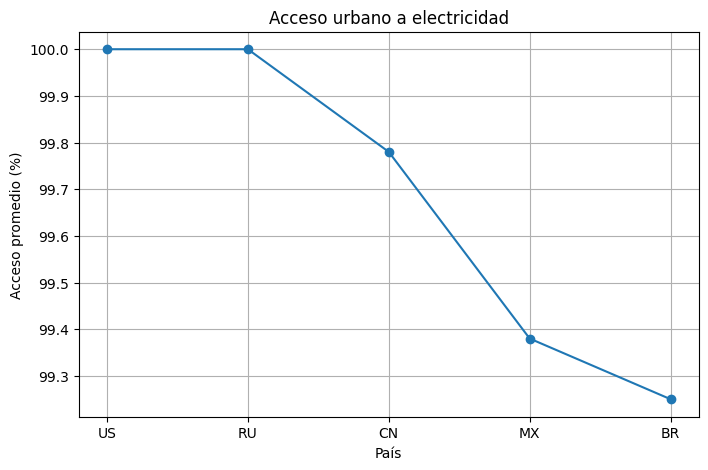

In [ ]:
resultado13 = pysqldf(consulta13)

plt.figure(figsize=(8,5))

plt.plot(
    resultado13['pais'],
    resultado13['acceso_urbano'],
    marker='o'
)

plt.title('Acceso urbano a electricidad')
plt.xlabel('País')
plt.ylabel('Acceso promedio (%)')

plt.grid(True)

plt.show()

### Interpretación

El análisis permite observar la cobertura eléctrica en las principales zonas urbanas y comparar las diferencias entre países.

## Gráfica 4. Consumo final de energía

Esta gráfica presenta una comparación del consumo final de energía entre los países incluidos en el estudio.

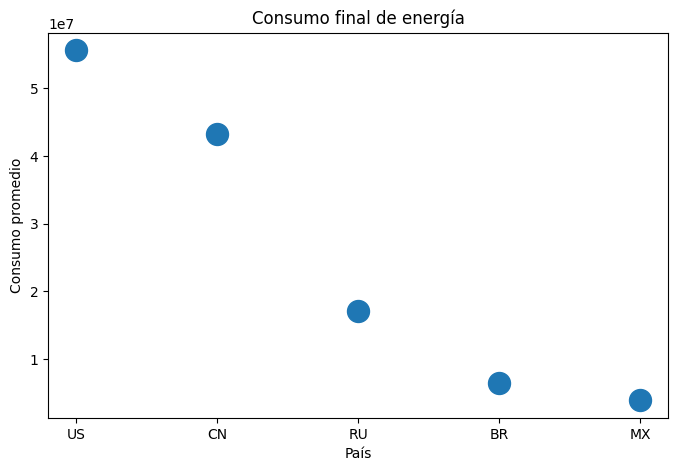

In [ ]:
resultado14 = pysqldf(consulta14)

plt.figure(figsize=(8,5))

plt.scatter(
    resultado14['pais'],
    resultado14['consumo_energia'],
    s=250
)

plt.title('Consumo final de energía')
plt.xlabel('País')
plt.ylabel('Consumo promedio')

plt.show()

### Interpretación

El consumo energético suele estar relacionado con el tamaño de la economía, el nivel de industrialización y las necesidades energéticas de la población.

## Gráfica 5. Participación de energías renovables

La siguiente visualización muestra la proporción promedio de energías renovables dentro del consumo energético total de cada país.

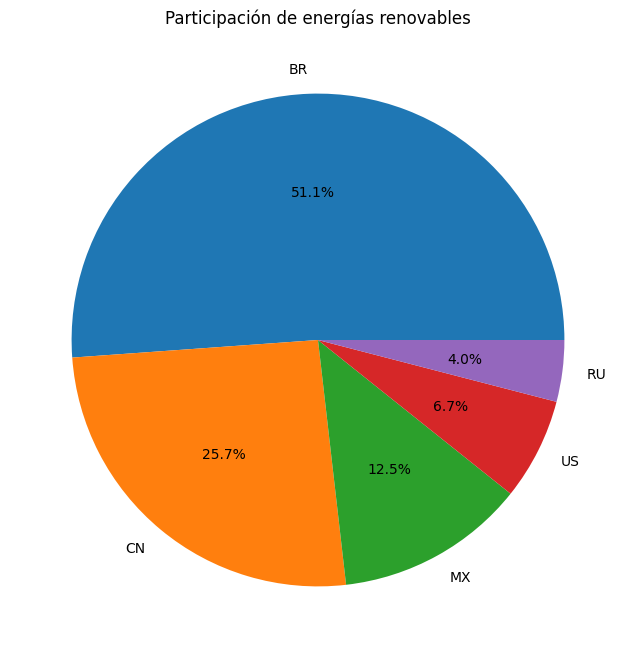

In [ ]:
resultado16 = pysqldf(consulta16)

plt.figure(figsize=(8,8))

plt.pie(
    resultado16['porcentaje_renovable'],
    labels=resultado16['pais'],
    autopct='%1.1f%%'
)

plt.title('Participación de energías renovables')

plt.show()

### Interpretación

La gráfica permite identificar qué países dependen en mayor medida de fuentes renovables para satisfacer sus necesidades energéticas y cuáles mantienen una mayor dependencia de fuentes convencionales.

# Conclusiones

A partir del análisis realizado se identificaron diferencias relevantes entre México, Estados Unidos, China, Brasil y Rusia en materia de acceso a electricidad y consumo energético.

Los resultados muestran que algunos países presentan mayores niveles de cobertura eléctrica y consumo de energías renovables, reflejando distintos niveles de desarrollo energético y adopción de fuentes sostenibles.

Las consultas SQL permitieron extraer información relevante del dataset, mientras que las visualizaciones facilitaron la comparación entre países y la identificación de patrones en los indicadores analizados.